## Зачем нужны модели для последовательностей

Последовательность — это данные, где порядок элементов важен.

Примеры:

- слова в предложении;
- символы в строке;
- значения временного ряда;
- клики пользователя;
- аудио-сигнал;
- кадры видео.

Если перемешать слова в предложении, смысл часто меняется. Поэтому модель должна учитывать не только сами элементы, но и их порядок, соседей и контекст.

Главная идея статьи: для последовательностей нужны представления элементов и архитектуры, которые умеют работать с порядком.


Для работы с такими данными есть несколько возможных режимов:

![Раздел архитектур для последовательностей](https://yastatic.net/s3/education-portal/media/sec_architectures_b7bc32c3d6_1_b98e97b208_f99654e141.svg)

## Word Embeddings

Bag of words

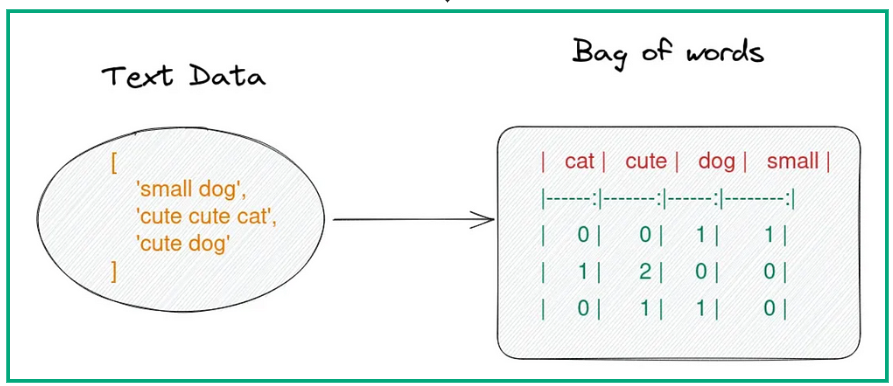

TF-IDF

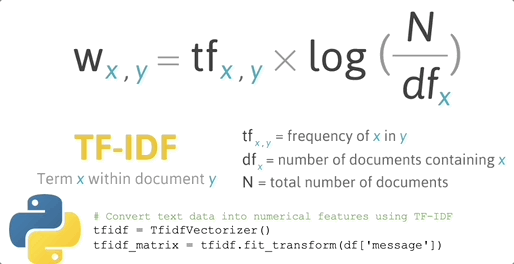

![]()

## Word2Vec: слова как векторы

Word2Vec учит для каждого слова числовой вектор. Близкие по употреблению слова получают похожие векторы.

Две классические схемы Word2Vec:

- CBOW: по соседним словам предсказываем центральное слово;
- Skip-gram: по центральному слову предсказываем соседние слова.

На практике Word2Vec часто используют как первый слой представления текста или как способ получить признаки для downstream-задач.

![CBOW и Skip-gram](https://yastatic.net/s3/education-portal/media/cbow_vs_skipgram_e3e32c275b_pngcbow_vs_skipgram_e3e32c275b_64c438dc03_0b778979eb.svg)


![CBOW: предсказание слова по контексту](https://yastatic.net/s3/education-portal/media/CBOW_a659160b42_1_ee8406db0b_a4873a5818.svg)


![Skip-gram: предсказание контекста по слову](https://yastatic.net/s3/education-portal/media/Skip_gram_b385df32ae_2_ba3f7892c2_56dcf3930a.svg)

### Что важно помнить про Word2Vec

Word2Vec не понимает грамматику как человек. Он просто учит такие векторы, чтобы слова из похожих контекстов располагались ближе.

Ограничения:

- одно слово получает один вектор, даже если у него несколько значений;
- порядок слов внутри широкой фразы учитывается слабо;
- качество зависит от размера корпуса;
- редкие слова обучаются хуже.

Эти ограничения стали одной из причин развития контекстных моделей, таких как ELMo, BERT и другие Transformer-модели.

## RNN: память для последовательности

Recurrent neural network читает последовательность по шагам.

На каждом шаге она получает:

- текущий элемент x_t;
- скрытое состояние прошлого шага h_{t-1}.

Затем строит новое скрытое состояние h_t.

Упрощенно:

    h_t = f(x_t, h_{t-1})

Смысл h_t: это сжатая память о том, что модель уже увидела.

Главное отличие от обычной полносвязной сети: RNN переиспользует одни и те же веса на каждом шаге последовательности.

![Рис. 8. RNN many-to-many](https://yastatic.net/s3/education-portal/media/ecurrent_many_to_many_08a3506cd8_fb323d4098_5eecbe06a7.svg)


### Bidirectional RNN

Одна RNN читает слева направо, другая справа налево. Это полезно, когда доступна вся последовательность, например при классификации текста.

Для онлайн-прогноза будущего bidirectional-модель использовать нельзя: она смотрит в будущее.

![Рис. 11. Bidirectional RNN](https://yastatic.net/s3/education-portal/media/recurrent_bidirectional1_f474990a9d_ca882b2008_25a0ba0240.svg)

## 5. LSTM и GRU

Обычная RNN плохо хранит длинные зависимости: градиенты могут затухать или взрываться.

LSTM и GRU добавляют gates — механизмы, которые решают, какую часть памяти сохранить, забыть или обновить.

### LSTM

В LSTM есть отдельная cell state — более длинная память.

Интуиция gates:

- forget gate: что забыть;
- input gate: что записать;
- output gate: что отдать наружу.

### GRU

GRU проще LSTM и часто работает как практичный компромисс.

Интуиция gates:

- update gate: сколько старой памяти оставить;
- reset gate: насколько забыть прошлое перед новым обновлением.

Практический совет: начните с GRU. Если нужно лучше ловить длинные зависимости, попробуйте LSTM или attention.


![Иллюстрация recurrent-блока 5](https://yastatic.net/s3/education-portal/media/img10_27a924e83a_a86b927eeb.webp)

## Seq2seq: генерация последовательностей

Seq2seq — это схема encoder-decoder.

Encoder читает входную последовательность и строит внутреннее представление. Decoder по этому представлению генерирует выходную последовательность.

Примеры:

- машинный перевод;
- суммаризация;
- генерация ответа;
- описание изображения;
- прогноз нескольких будущих шагов.

Главная проблема простого seq2seq: если вся входная последовательность сжимается в один вектор, длинный контекст теряется. Attention решает это лучше.

![Рис. 17. Вероятностная модель последовательности](https://yastatic.net/s3/education-portal/media/prob_ML_1_NN_copy_653b463de1_b4f83f4eda.svg)